# Order Flow Alpha Lab

For this project, one of my goal is to learn how the strategy emerges in the market because I am curious about how buy/sell could infer information about what will happen in the market. This strategy is backed with theory called Auction Market Theory, aside from this you would be able to understand the mircroeconomic structure behind the strategy.

One question arises,

> Does short-term order flow imbalance contains information about the future BTC price movements?

We will go through order flow real trades, buy/sell classification, order-flow imbalance, studying its features, dealing with hypothesis, backtest, transaction cost and out of sample test.

This project is just for the purpose of learning and curiosity about the order-flow strategy in trading.

## Install libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn requests scipy scikit-learn

In [2]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.metrics import classification_report, roc_auc_score

pd.set_option("display.max_columns", 100)

## Download real binance trade data

We are using Binance's public market-data endpoint. Binance documents $aggTrades$ a s aggregated executions from taker order, and its public market-data API does not require authentication.

In [6]:
BASE_URL = "https://data-api.binance.vision/api/v3/aggTrades"

SYMBOL = "BTCUSDT"

def get_aggtrades(end_time=None, limit=1000):

    params = {
        "symbol": SYMBOL,
        "limit": limit
    }

    if end_time is not None:
        params["endTime"] = int(end_time)

    r = requests.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()

    return r.json()

Test the API

In [7]:
sample = get_aggtrades(limit=5)

sample

[{'a': 4070448027,
  'p': '85334.00000000',
  'q': '0.00007000',
  'f': 6702591339,
  'l': 6702591339,
  'T': 1790058398717,
  'm': True,
  'M': True},
 {'a': 4070448028,
  'p': '85334.00000000',
  'q': '0.00006000',
  'f': 6702591340,
  'l': 6702591340,
  'T': 1790058399040,
  'm': True,
  'M': True},
 {'a': 4070448029,
  'p': '85334.00000000',
  'q': '0.00007000',
  'f': 6702591341,
  'l': 6702591341,
  'T': 1790058399240,
  'm': True,
  'M': True},
 {'a': 4070448030,
  'p': '85334.00000000',
  'q': '0.00007000',
  'f': 6702591342,
  'l': 6702591342,
  'T': 1790058399734,
  'm': True,
  'M': True},
 {'a': 4070448031,
  'p': '85334.00000000',
  'q': '0.00007000',
  'f': 6702591343,
  'l': 6702591343,
  'T': 1790058399888,
  'm': True,
  'M': True}]

## Download approximately 30,000 recent trades

In [8]:
def download_trades(n_batches=30):

    all_data = []
    end_time = None

    for i in range(n_batches):

        data = get_aggtrades(
            end_time=end_time,
            limit=1000
        )

        if not data:
            break

        all_data.extend(data)

        oldest_time = min(x["T"] for x in data)
        end_time = oldest_time - 1

        print(
            f"Batch {i+1}/{n_batches} | "
            f"Trades collected: {len(all_data):,}"
        )

        time.sleep(0.15)

    return all_data


raw_trades = download_trades(n_batches=30)

len(raw_trades)

Batch 1/30 | Trades collected: 1,000
Batch 2/30 | Trades collected: 2,000
Batch 3/30 | Trades collected: 3,000
Batch 4/30 | Trades collected: 4,000
Batch 5/30 | Trades collected: 5,000
Batch 6/30 | Trades collected: 6,000
Batch 7/30 | Trades collected: 7,000
Batch 8/30 | Trades collected: 8,000
Batch 9/30 | Trades collected: 9,000
Batch 10/30 | Trades collected: 10,000
Batch 11/30 | Trades collected: 11,000
Batch 12/30 | Trades collected: 12,000
Batch 13/30 | Trades collected: 13,000
Batch 14/30 | Trades collected: 14,000
Batch 15/30 | Trades collected: 15,000
Batch 16/30 | Trades collected: 16,000
Batch 17/30 | Trades collected: 17,000
Batch 18/30 | Trades collected: 18,000
Batch 19/30 | Trades collected: 19,000
Batch 20/30 | Trades collected: 20,000
Batch 21/30 | Trades collected: 21,000
Batch 22/30 | Trades collected: 22,000
Batch 23/30 | Trades collected: 23,000
Batch 24/30 | Trades collected: 24,000
Batch 25/30 | Trades collected: 25,000
Batch 26/30 | Trades collected: 26,000
Batc

30000

## Convert into a DataFrame

In [9]:
df = pd.DataFrame(raw_trades)

df.head()

,a,p,q,f,l,T,m,M
0,4070447397,85282.10000000,0.01042000,6702589160,6702589160,1790058357535,False,True
1,4070447398,85282.14000000,0.00006000,6702589161,6702589161,1790058357535,False,True
2,4070447399,85282.47000000,0.00013000,6702589162,6702589162,1790058357535,False,True
3,4070447400,85282.86000000,0.00006000,6702589163,6702589163,1790058357535,False,True
4,4070447401,85283.28000000,0.00013000,6702589164,6702589164,1790058357535,False,True


Renaming columns

In [10]:
df = df.rename(columns={
    "a": "trade_id",
    "p": "price",
    "q": "quantity",
    "f": "first_trade_id",
    "l": "last_trade_id",
    "T": "timestamp",
    "m": "buyer_maker"
})

## Convert types

In [11]:
df["price"] = df["price"].astype(float)
df["quantity"] = df["quantity"].astype(float)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    unit="ms",
    utc=True
)

df = df.sort_values("timestamp").drop_duplicates("trade_id")

df.reset_index(drop=True, inplace=True)

df.head()

,trade_id,price,quantity,first_trade_id,last_trade_id,timestamp,buyer_maker,M
0,4070418242,85382.74,0.01227,6702521125,6702521127,2026-09-22 05:42:03.179000+00:00,False,True
1,4070418272,85388.15,0.00200,6702521173,6702521173,2026-09-22 05:42:03.179000+00:00,False,True
2,4070418271,85388.15,0.03357,6702521172,6702521172,2026-09-22 05:42:03.179000+00:00,False,True
3,4070418270,85388.07,0.00012,6702521171,6702521171,2026-09-22 05:42:03.179000+00:00,False,True
4,4070418269,85388.01,0.02200,6702521167,6702521170,2026-09-22 05:42:03.179000+00:00,False,True


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   trade_id        30000 non-null  int64              
 1   price           30000 non-null  float64            
 2   quantity        30000 non-null  float64            
 3   first_trade_id  30000 non-null  int64              
 4   last_trade_id   30000 non-null  int64              
 5   timestamp       30000 non-null  datetime64[ns, UTC]
 6   buyer_maker     30000 non-null  bool               
 7   M               30000 non-null  bool               
dtypes: bool(2), datetime64[ns, UTC](1), float64(2), int64(3)
memory usage: 1.4 MB


## Understanding what buyer_maker means

If buyer_maker is True means the buyer was the maker, that means the aggresive participant was the seller. Therefore selling pressure emerges. Whereas, if buyer_maker is False it means that agressive participant was the buyer, hence, buying pressure emerges.

## Create signed order flow

In [13]:
df["side"] = np.where(
    df["buyer_maker"],
    "SELL",
    "BUY"
)

Now calculate dollar/national volume:

In [14]:
df["notional"] = df["price"] * df["quantity"]

Add signed volume:

In [15]:
df["signed_volume"] = np.where(
    df["side"] == "BUY",
    df["quantity"],
    -df["quantity"]
)

Also signed dollar flow:

In [16]:
df["signed_notional"] = np.where(
    df["side"] == "BUY",
    df["notional"],
    -df["notional"]
)

In [17]:
df[
    [
        "timestamp",
        "price",
        "quantity",
        "side",
        "notional",
        "signed_notional"
    ]
].head(20)

,timestamp,price,quantity,side,notional,signed_notional
0,2026-09-22 05:42:03.179000+00:00,85382.74,0.01227,BUY,1047.646220,1047.646220
1,2026-09-22 05:42:03.179000+00:00,85388.15,0.00200,BUY,170.776300,170.776300
2,2026-09-22 05:42:03.179000+00:00,85388.15,0.03357,BUY,2866.480195,2866.480195
3,2026-09-22 05:42:03.179000+00:00,85388.07,0.00012,BUY,10.246568,10.246568
4,2026-09-22 05:42:03.179000+00:00,85388.01,0.02200,BUY,1878.536220,1878.536220
5,2026-09-22 05:42:03.179000+00:00,85387.88,0.00009,BUY,7.684909,7.684909
6,2026-09-22 05:42:03.179000+00:00,85387.77,0.00013,BUY,11.100410,11.100410
7,2026-09-22 05:42:03.179000+00:00,85387.64,0.00012,BUY,10.246517,10.246517
8,2026-09-22 05:42:03.179000+00:00,85387.50,0.00007,BUY,5.977125,5.977125
9,2026-09-22 05:42:03.179000+00:00,85386.96,0.00013,BUY,11.100305,11.100305


## Visualize the actual trades

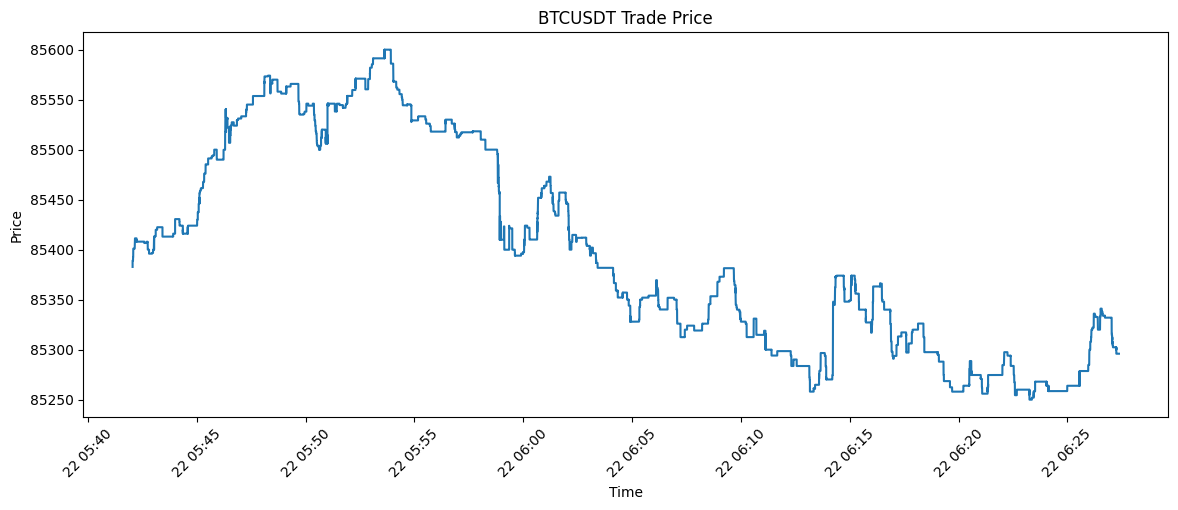

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["price"]
)

plt.title("BTCUSDT Trade Price")
plt.xlabel("Time")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.show()

Here, we are not working with candlesticks. We are working with individual market executions.

## Aggregate trades into 1-minute buckets

Microstructure data is extremely noisy.

In [19]:
df = df.set_index("timestamp")

bars = df.resample("1min").agg(
    price=("price", "last"),
    volume=("quantity", "sum"),
    notional=("notional", "sum"),
    signed_volume=("signed_volume", "sum"),
    signed_notional=("signed_notional", "sum"),
    trades=("trade_id", "count")
)

bars.head()

,price,volume,notional,signed_volume,signed_notional,trades
timestamp,,,,,,
2026-09-22 05:42:00+00:00,85399.99,12.13920,1.036738e+06,6.57730,5.617189e+05,1000
2026-09-22 05:43:00+00:00,85416.00,8.11408,6.930364e+05,2.52558,2.156947e+05,461
2026-09-22 05:44:00+00:00,85424.01,8.67720,7.412325e+05,3.69542,3.156724e+05,401
2026-09-22 05:45:00+00:00,85489.99,21.96986,1.877993e+06,-0.27104,-2.344981e+04,988
2026-09-22 05:46:00+00:00,85531.14,28.59385,2.445260e+06,13.71865,1.173046e+06,1231


Now calculate buy and sell volume.

In [20]:
buy_volume = (
    df["quantity"]
    .where(df["side"] == "BUY", 0)
    .resample("1min")
    .sum()
)

sell_volume = (
    df["quantity"]
    .where(df["side"] == "SELL", 0)
    .resample("1min")
    .sum()
)

bars["buy_volume"] = buy_volume
bars["sell_volume"] = sell_volume

In [22]:
bars

,price,volume,notional,signed_volume,signed_notional,trades,buy_volume,sell_volume
timestamp,,,,,,,,
2026-09-22 05:42:00+00:00,85399.99,12.13920,1.036738e+06,6.57730,5.617189e+05,1000,9.35825,2.78095
2026-09-22 05:43:00+00:00,85416.00,8.11408,6.930364e+05,2.52558,2.156947e+05,461,5.31983,2.79425
2026-09-22 05:44:00+00:00,85424.01,8.67720,7.412325e+05,3.69542,3.156724e+05,401,6.18631,2.49089
2026-09-22 05:45:00+00:00,85489.99,21.96986,1.877993e+06,-0.27104,-2.344981e+04,988,10.84941,11.12045
2026-09-22 05:46:00+00:00,85531.14,28.59385,2.445260e+06,13.71865,1.173046e+06,1231,21.15625,7.43760
2026-09-22 05:47:00+00:00,85553.65,4.09555,3.503564e+05,0.33279,2.845252e+04,408,2.21417,1.88138
2026-09-22 05:48:00+00:00,85556.09,7.08426,6.061575e+05,3.02726,2.590174e+05,829,5.05576,2.02850
2026-09-22 05:49:00+00:00,85538.01,6.37295,5.452347e+05,1.88365,1.611668e+05,459,4.12830,2.24465
2026-09-22 05:50:00+00:00,85506.12,6.32016,5.404616e+05,-2.12340,-1.815775e+05,994,2.09838,4.22178


## Calculate Order Flow Imbalance

Here's our primary microstructure variable:

$$
\mathrm{OFI} =
\frac{V_{\mathrm{buy}} - V_{\mathrm{sell}}}
{V_{\mathrm{buy}} + V_{\mathrm{sell}}}
$$
	​


In [23]:
bars["ofi"] = (
    (bars["buy_volume"] - bars["sell_volume"]) /
    (bars["buy_volume"] + bars["sell_volume"])
)

$$
\begin{aligned}
\mathrm{OFI} &\approx +1 && \quad \text{Extremely buy-dominated} \\
\mathrm{OFI} &\approx 0  && \quad \text{Balanced buying and selling} \\
\mathrm{OFI} &\approx -1 && \quad \text{Extremely sell-dominated}
\end{aligned}
$$

In [24]:
bars["ofi"].describe()

,ofi
count,46.000000
mean,-0.092125
std,0.525648
min,-0.861072
25%,-0.575917
50%,-0.164569
75%,0.397222
max,0.904482


## Plot Order Flow

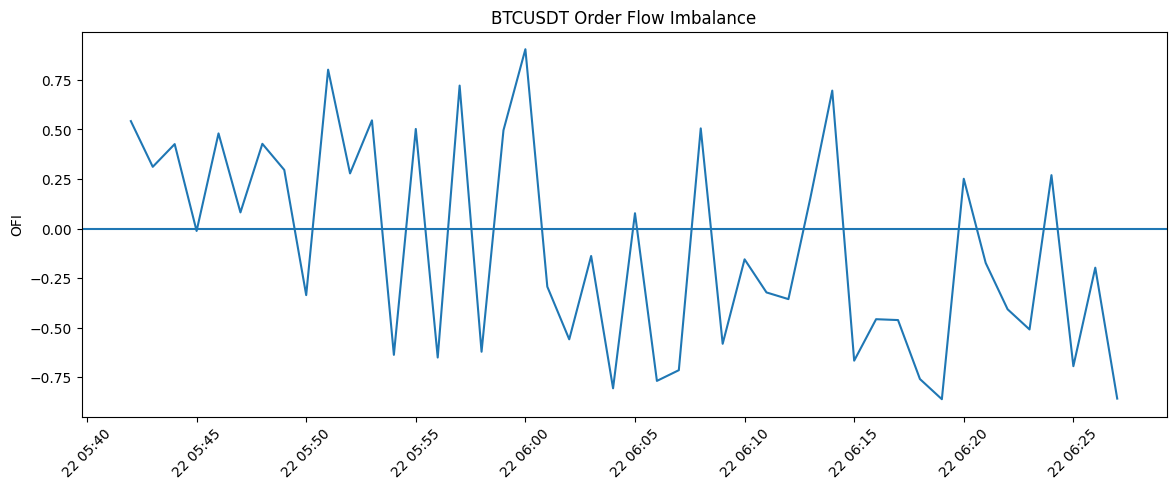

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    bars.index,
    bars["ofi"]
)

plt.axhline(0)

plt.title("BTCUSDT Order Flow Imbalance")
plt.ylabel("OFI")

plt.xticks(rotation=45)
plt.show()

This is pretty much different from what traditional technical analysis give us. We are now seeing in a way how buyers and sellers doing tug-of-war.

Question arises from this plot such as,

> Who is aggresively transating?

rather than simply saying

> What shape did the candle make?

## Now we calculate the returns

In [26]:
bars["return_1m"] = bars["price"].pct_change()

Future return:

In [27]:
bars["future_return_1m"] = (
    bars["price"].shift(-1) / bars["price"] - 1
)

And a 5-minute future return

In [28]:
bars["future_return_5m"] = (
    bars["price"].shift(-5) / bars["price"] - 1
)

## Research Hypothesis

Hypothesis:

> Strong positive order-flow imbalance should be associated with positive subsequent returns.


We can divide OFI into quantiles.

In [29]:
bars["ofi_quantile"] = pd.qcut(
    bars["ofi"],
    5,
    labels=[
        "Very Low",
        "Low",
        "Neutral",
        "High",
        "Very High"
    ]
)

Calculate future returns:

In [30]:
group_returns = (
    bars
    .groupby("ofi_quantile", observed=True)["future_return_5m"]
    .agg(["mean", "median", "std", "count"])
)

group_returns

,mean,median,std,count
ofi_quantile,,,,
Very Low,-0.000512,-0.000456,0.000506,8
Low,-0.000124,-0.000026,0.000525,8
Neutral,-0.000077,-0.000032,0.000542,8
High,0.000397,0.000292,0.000763,8
Very High,-0.000781,-0.001066,0.001071,9


## Visualizing the relationship

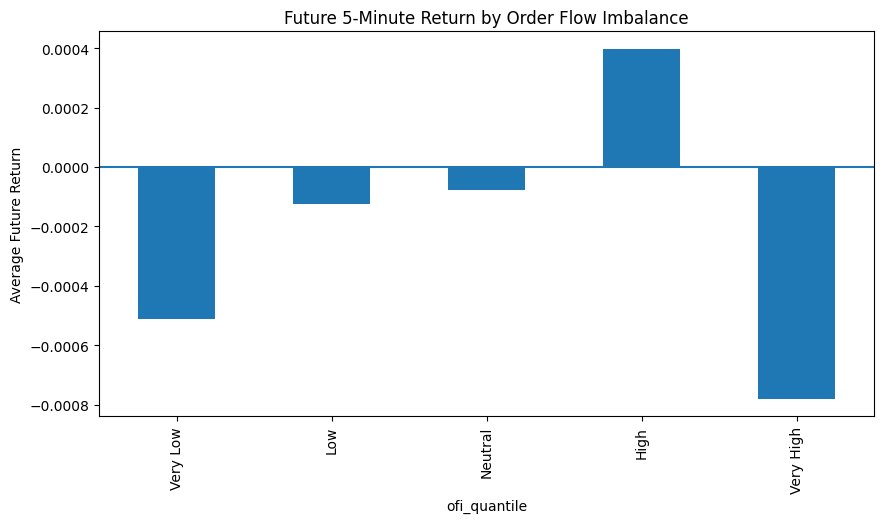

In [31]:
group_returns["mean"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0)

plt.title(
    "Future 5-Minute Return by Order Flow Imbalance"
)

plt.ylabel("Average Future Return")

plt.show()

## Test Correlation

In [32]:
clean = bars[
    ["ofi", "future_return_5m"]
].dropna()

corr, pvalue = stats.pearsonr(
    clean["ofi"],
    clean["future_return_5m"]
)

print("Correlation:", corr)
print("P-value:", pvalue)

Correlation: -0.020600673981636706
P-value: 0.8982733761651005


## Spearman correlation

In [33]:
spearman_corr, spearman_p = stats.spearmanr(
    clean["ofi"],
    clean["future_return_5m"]
)

print("Spearman correlation:", spearman_corr)
print("P-value:", spearman_p)

Spearman correlation: -0.0815331010452962
P-value: 0.6123186109700567


## Create a simple order-flow strategy

Now we turn the research hypothesis into a trading rule.

Let's say for example:

> OFI > 0.30 --> LONG

> OFI < -0.30 --> SHORT

Otherwise,

> NO TRADE

In [34]:
 bars["signal"] = 0

bars.loc[bars["ofi"] > 0.30, "signal"] = 1
bars.loc[bars["ofi"] < -0.30, "signal"] = -1

## Avoiding look-ahead bias

We cannot use the current minute's completed order flow to pretend we entered at the beginning of the same minimute. So we shift the signal

In [36]:
bars["position"] = bars["signal"].shift(1)

Now the strategy uses:

$$ OFI_t \rightarrow signal_t \rightarrow position_{t+1} $$

rather than cheating with future information.

## Strategy returns

In [37]:
bars["strategy_return"] = (
    bars["position"] *
    bars["return_1m"]
)

Calculate cumulative performance

In [40]:
bars["equity"] = (
    1 + bars["strategy_return"].fillna(0)
).cumprod()

Plot

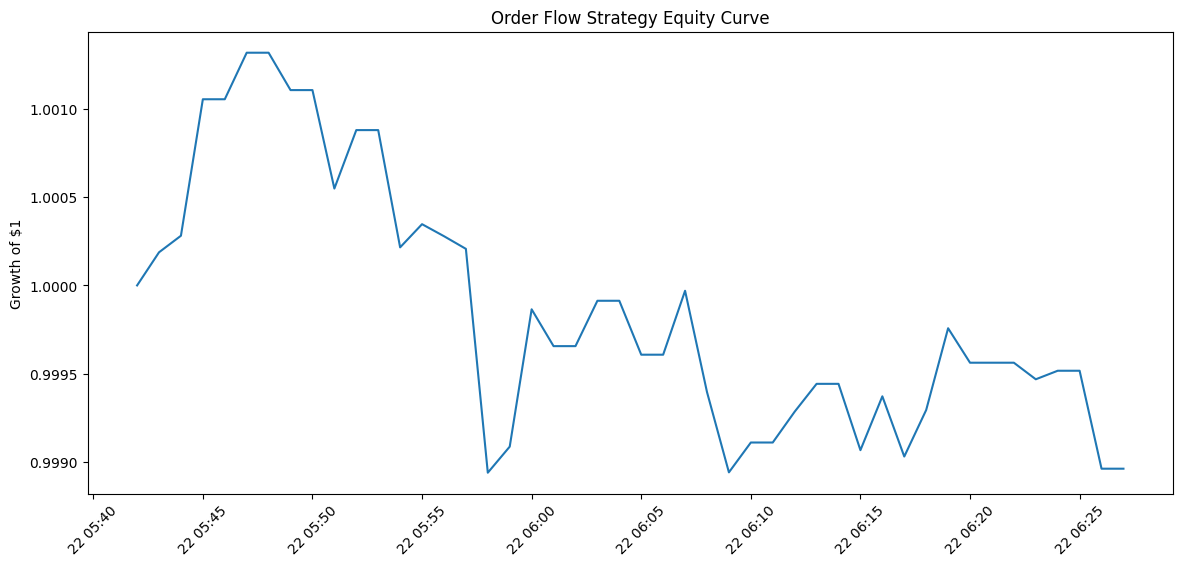

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(
    bars.index,
    bars["equity"]
)

plt.title("Order Flow Strategy Equity Curve")

plt.ylabel("Growth of $1")

plt.xticks(rotation=45)

plt.show()

## Adding transaction costs

Suppose we assume:

In [42]:
COST = 0.0005

That's about 0.05 % per trade

Calculate turnover:

In [44]:
bars["trade"] = (
    bars["position"]
    .diff()
    .abs()
)

Apply costs

In [45]:
bars["strategy_return_net"] = (
    bars["strategy_return"]
    -
    bars["trade"] * COST
)

In [46]:
bars["equity_net"] = (
    1 + bars["strategy_return_net"].fillna(0)
).cumprod()

Plotting it both

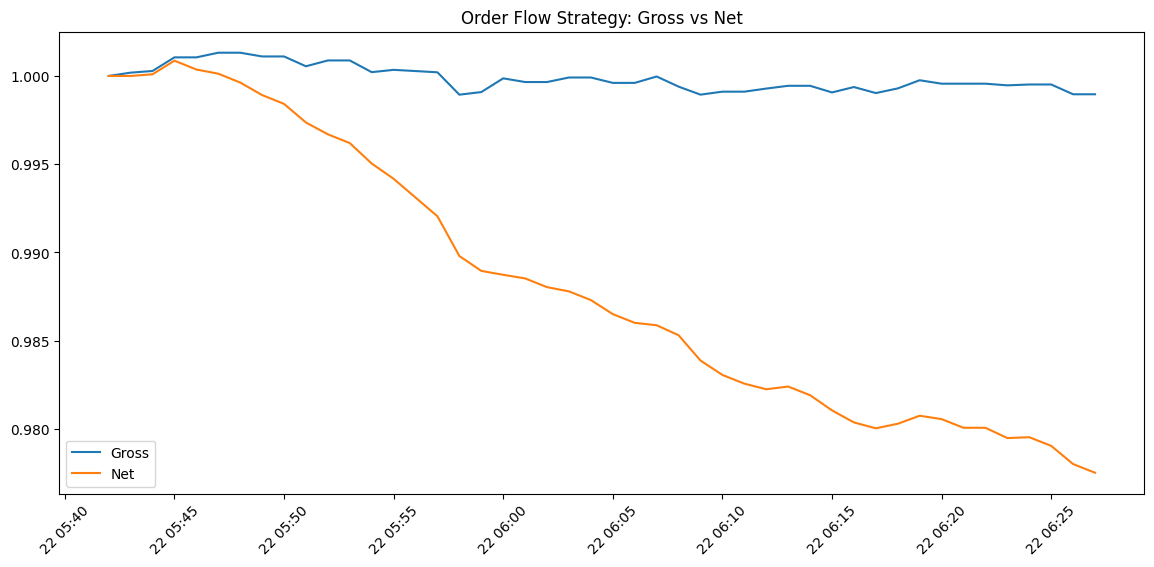

In [47]:
plt.figure(figsize=(14, 6))

plt.plot(
    bars.index,
    bars["equity"],
    label="Gross"
)

plt.plot(
    bars.index,
    bars["equity_net"],
    label="Net"
)

plt.title("Order Flow Strategy: Gross vs Net")

plt.legend()

plt.xticks(rotation=45)

plt.show()

## Calculate performance statistics

In [48]:
returns = bars["strategy_return_net"].dropna()

total_return = (1 + returns).prod() - 1

annualized_return = (
    (1 + total_return)
    ** (365 * 24 * 60 / len(returns))
    - 1
)

annualized_vol = (
    returns.std() *
    np.sqrt(365 * 24 * 60)
)

sharpe = (
    annualized_return / annualized_vol
    if annualized_vol != 0 else np.nan
)

win_rate = (
    (returns > 0).mean()
)

print("Total return:", total_return)
print("Annualized return:", annualized_return)
print("Annualized volatility:", annualized_vol)
print("Sharpe:", sharpe)
print("Win rate:", win_rate)

Total return: -0.022477701432570774
Annualized return: -1.0
Annualized volatility: 0.37494316161451086
Sharpe: -2.6670709120123304
Win rate: 0.13636363636363635


## Maximum drawdown

In [49]:
equity = bars["equity_net"].dropna()

running_max = equity.cummax()

drawdown = (
    equity / running_max - 1
)

max_drawdown = drawdown.min()

print(
    "Maximum drawdown:",
    max_drawdown
)

Maximum drawdown: -0.02332372884316003


Plot

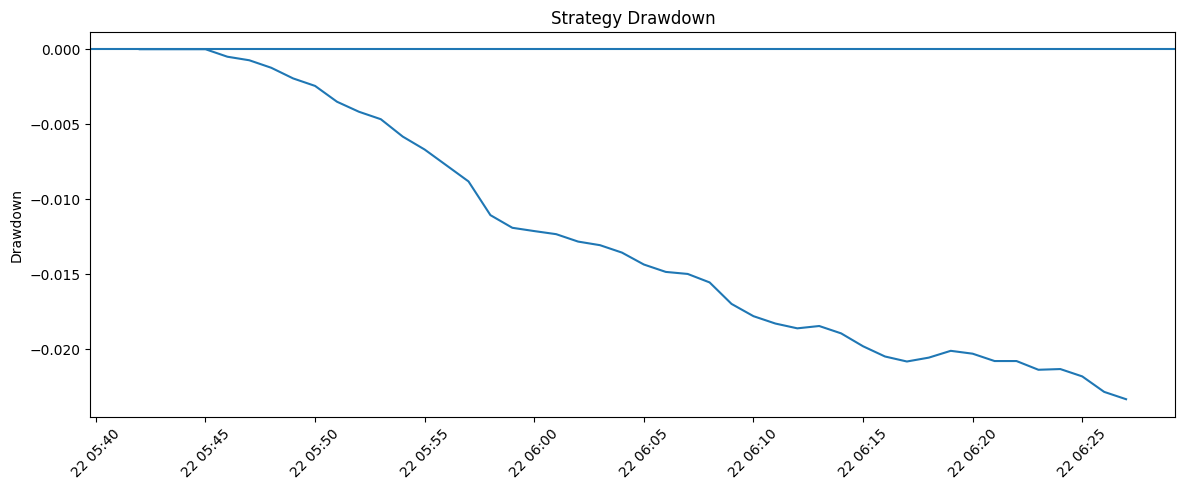

In [50]:
plt.figure(figsize=(14, 5))

plt.plot(
    drawdown.index,
    drawdown
)

plt.axhline(0)

plt.title("Strategy Drawdown")

plt.ylabel("Drawdown")

plt.xticks(rotation=45)

plt.show()

## Machine learning extension

Create additional features:

In [51]:
bars["ofi_3"] = bars["ofi"].rolling(3).mean()

bars["ofi_5"] = bars["ofi"].rolling(5).mean()

bars["ofi_10"] = bars["ofi"].rolling(10).mean()

bars["volume_z"] = (
    (bars["volume"] - bars["volume"].rolling(30).mean())
    /
    bars["volume"].rolling(30).std()
)

bars["return_1"] = bars["price"].pct_change()

bars["volatility"] = (
    bars["return_1"]
    .rolling(20)
    .std()
)

Create target:

In [52]:
bars["target"] = (
    bars["future_return_5m"] > 0
).astype(int)

## ML dataset

In [53]:
features = [
    "ofi",
    "ofi_3",
    "ofi_5",
    "ofi_10",
    "volume_z",
    "return_1",
    "volatility"
]

ml_data = bars[
    features + ["target"]
].dropna()

X = ml_data[features]
y = ml_data["target"]

## Time-series train/test split

Use chronological splitting.

In [54]:
split = int(len(ml_data) * 0.70)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

## Using logistic regression

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [56]:
probabilities = model.predict_proba(X_test)[:, 1]

predictions = (
    probabilities > 0.5
).astype(int)

## Evaluating the performance

In [57]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.17      1.00      0.29         1

    accuracy                           0.17         6
   macro avg       0.08      0.50      0.14         6
weighted avg       0.03      0.17      0.05         6



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


AUC:

In [58]:
auc = roc_auc_score(
    y_test,
    probabilities
)

print("Out-of-sample ROC-AUC:", auc)

Out-of-sample ROC-AUC: 0.0


## Examine which features matter

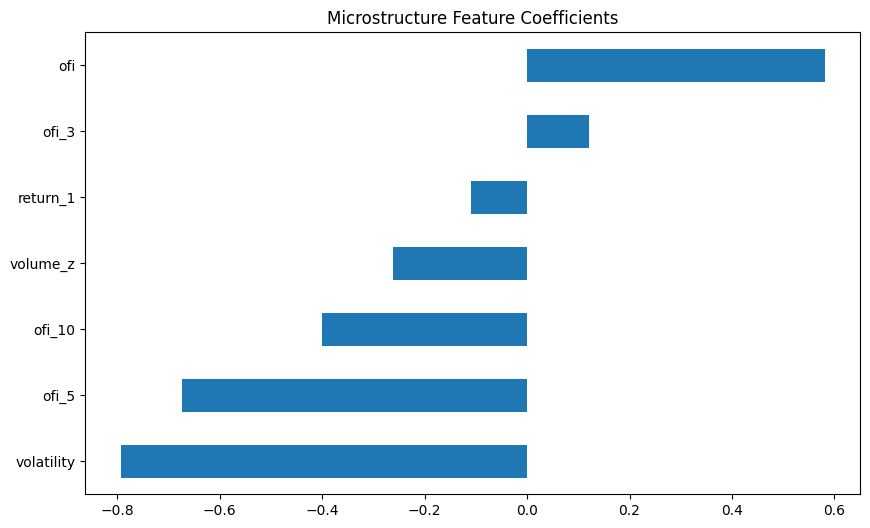

In [59]:
coefs = pd.Series(
    model.named_steps["model"].coef_[0],
    index=features
)

coefs.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Microstructure Feature Coefficients")

plt.show()